<a id="top"></a>
# Apple Stock Turnover

## Table of Contents

- [Data Exploration](#data-exploration)
- [Data Cleaning](#data-cleaning)
- [Data Analysis and Visualization](#data-analysis)
  - [Roadmap](#roadmap)
  - [Step 1: Isolate the Data](#step-1)
  - [Step 2: Data Visualization](#step-2)
  - [Step 3: Regression Analysis](#step-3)
  - [Step 4: Machine Learning (XGBoost)](#step-4)
- [Conclusions, Findings and Recommendations](#conclusions)

In [25]:
##import libraries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sklearn 
import statsmodels.api as sm

In [9]:
## Load the Data 
df = pd.read_csv('model_ready_table.csv')

##Data Exploration

Let's look at how many columns we have, what the head and tail looks like, how many managers we have in total, and across how many periods this data spans

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144370 entries, 0 to 144369
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   accession_number             144370 non-null  str    
 1   cik                          144370 non-null  int64  
 2   filingmanager_name           144370 non-null  str    
 3   periodofreport               144370 non-null  str    
 4   aapl_value                   144370 non-null  int64  
 5   aapl_shares                  144370 non-null  int64  
 6   pct_change_value             135720 non-null  float64
 7   target_increased             135822 non-null  float64
 8   manager_position_count       144370 non-null  int64  
 9   is_index_fund_flag           144370 non-null  int64  
 10  manager_total_aum_corrected  144370 non-null  int64  
 11  pct_of_manager_aum           144357 non-null  float64
 12  total_abs_position_change    135822 non-null  float64
 13  manager_tu

In [11]:
df.head(5)

,accession_number,cik,filingmanager_name,periodofreport,aapl_value,aapl_shares,pct_change_value,target_increased,manager_position_count,is_index_fund_flag,...,yield_spread_10y_2y,fed_funds_rate_change_qoq,cpi_yoy_pct,vix,aapl_price_return,aapl_realized_volatility,spy_return,megacap_peer_avg_return,earnings_surprise_pct,trailing_pe
0,0000002230-18-000018,2230,"ADAMS DIVERSIFIED EQUITY FUND, INC.",31-DEC-2017,80130,473500,0.0,0.0,204,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000002230-18-000023,2230,"ADAMS DIVERSIFIED EQUITY FUND, INC.",31-MAR-2018,66508000,396400,0.0,0.0,211,0,...,0.47,NaN,NaN,17.354754,NaN,0.135064,NaN,NaN,1.4870,NaN
2,0000007195-18-000001,7195,"ARGUS INVESTORS' COUNSEL, INC.",31-DEC-2017,4390,25941,0.0,0.0,51,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0000007195-18-000002,7195,"ARGUS INVESTORS' COUNSEL, INC.",31-MAR-2018,4126000,26771,0.0,0.0,51,0,...,0.47,NaN,NaN,17.354754,NaN,0.135064,NaN,NaN,1.4870,NaN
4,0000007195-18-000003,7195,"ARGUS INVESTORS' COUNSEL, INC.",30-JUN-2018,4990000,26957,NaN,NaN,69,0,...,0.33,0.31,NaN,15.337500,0.107545,0.106244,0.035524,0.103379,7.3394,NaN


In [12]:
df.tail(5)

,accession_number,cik,filingmanager_name,periodofreport,aapl_value,aapl_shares,pct_change_value,target_increased,manager_position_count,is_index_fund_flag,...,yield_spread_10y_2y,fed_funds_rate_change_qoq,cpi_yoy_pct,vix,aapl_price_return,aapl_realized_volatility,spy_return,megacap_peer_avg_return,earnings_surprise_pct,trailing_pe
144365,0002136442-26-000001,2136442,Essential Partners LLC,31-MAR-2026,1785092,7034,0.0,0.0,2848,0,...,0.51,-0.08,3.285958,20.429048,-0.065595,0.124895,-0.043706,-0.127703,3.6082,30.633360
144366,0002136442-26-000002,2136442,Essential Partners LLC,31-DEC-2025,1874637,6896,0.0,1.0,2772,0,...,0.71,-0.50,2.653304,17.745231,0.068702,0.086959,0.026652,0.030761,6.3670,34.275855
144367,0002136442-26-000003,2136442,Essential Partners LLC,30-SEP-2025,1621599,6368,0.0,1.0,2668,0,...,0.56,-0.11,3.022572,15.983030,0.242477,0.123478,0.081212,0.150090,4.5198,33.961562
144368,0002136442-26-000004,2136442,Essential Partners LLC,30-JUN-2025,1211953,5907,NaN,NaN,2273,0,...,0.52,0.00,2.680454,23.561406,-0.075141,0.251014,0.107772,0.301977,9.7902,30.983786
144369,0002136913-26-000002,2136913,Krane Financial Solutions LLC,31-MAR-2026,5531007,21794,NaN,NaN,48,0,...,0.51,-0.08,3.285958,20.429048,-0.065595,0.124895,-0.043706,-0.127703,3.6082,30.633360


In [24]:
df['filingmanager_name'].unique()


<StringArray>
['ADAMS DIVERSIFIED EQUITY FUND, INC.',      'ARGUS INVESTORS' COUNSEL, INC.',
          'ASSET PLANNING CORPORATION',       'UDINE WEALTH MANAGEMENT, INC.',
                'ASSOCIATED BANC-CORP',                'Associated Banc-Corp',
                         'BARINGS LLC',        'BANK OF NOVA SCOTIA TRUST CO',
                 'SCOTIA CAPITAL INC.',                 'BANK OF NOVA SCOTIA',
 ...
             'Walsh & Associates, LLC',              '3 FACTOR INDEXING, LLC',
             'PlanVest Financial, Inc',               'Purewater Capital LLC',
        'Encore Global Management, LP',           'SIMA Wealth Partners, LLC',
          'Cornerstone Wealth, LLC/TN',  'Orographic Financial Advisors, LLC',
              'Essential Partners LLC',       'Krane Financial Solutions LLC']
Length: 9443, dtype: str

In [22]:
df['periodofreport'].unique()

<StringArray>
['31-DEC-2017', '31-MAR-2018', '30-JUN-2018', '30-SEP-2018', '31-DEC-2018',
 '31-MAR-2019', '30-JUN-2019', '30-SEP-2019', '31-DEC-2019', '31-MAR-2020',
 '30-JUN-2020', '30-SEP-2020', '31-DEC-2020', '31-MAR-2021', '30-JUN-2021',
 '30-SEP-2021', '31-DEC-2021', '31-MAR-2022', '30-JUN-2022', '30-SEP-2022',
 '31-DEC-2022', '31-MAR-2023', '30-JUN-2023', '30-SEP-2023', '31-DEC-2023',
 '31-MAR-2024', '30-JUN-2024', '30-SEP-2024', '31-DEC-2024', '31-MAR-2025',
 '30-JUN-2025', '30-SEP-2025', '31-DEC-2025', '31-MAR-2026', '31-MAR-2017',
 '30-SEP-2017', '30-JUN-2017', '31-DEC-2016', '31-DEC-2014', '31-MAR-2015',
 '30-SEP-2015', '31-DEC-2015', '31-MAR-2016', '30-JUN-2014', '30-SEP-2014',
 '30-JUN-2015', '30-JUN-2016', '30-SEP-2016', '31-DEC-2012', '31-MAR-2013',
 '30-JUN-2013', '30-SEP-2013', '31-DEC-2013', '31-MAR-2014', '31-DEC-2006',
 '31-MAR-2007', '30-JUN-2007', '30-SEP-2007', '31-DEC-2007', '31-MAR-2008',
 '30-JUN-2008', '30-SEP-2008', '31-DEC-2008', '30-JUN-2009', '30-SEP-2009'

There are 9443 unique managers, and data about holding that spans 79 periods. That is clearly an error, and there seems to be a lot of null data, so we must address these issues in the data cleaning phase. 

##Data Cleaning 

steps: 

1. Data Type/Structure Cleaning:  
- "periodofreport" is a string, change to datetime
- strip string for filingmanager_name for consistency
- check "periodofreport" matches the end of the quarter 

2. Range of Dates to include for project
- 1987-2016 are out of scope of the project, and have no macro data match. Only keeping >= 2017-12-31

3. Duplicates inspection / Dropping
- inspect the duplicates for "cik" and "periodofreport" and drop if there are any

4. Drop Invalid "aapl_shares" rows 
- basis for target variable: needs to be positive. 

5. Check for share prices 
- calculate "implied_price" of apple stock, and flag values that are more than 10% away from the typical stock prices from the quarter  

6. Account for 2020 Apple Split Shares
- Shares jump 4x in 2020Q3, not accounted for in data joining.

7. Consistent holdings per quarter and normalize changes across quarters
- Checks to see if there are gaps in quarterly holdings that could skew data 
- Normalize holding levels to changes across quarters. Prepares data better for Regression Analysis and Machine Learning 

8. Consistent Asset Manager % across quarters 
- Check to see if there are gaps in quarterly % of apple portfolio 
- feature engineer data if there are missing values 

9. Check for missing data that is grouped by Macro data 
- After cleaning, check to see if there are any gaps in the data. 

In [27]:
#Data Cleaning Tracking 

steps = {"raw": len(df)}

In [ ]:
#1 Data Types/Structure Cleaning

df["periodofreport"] = pd.to_datetime(df["periodofreport"], format="%d-%b-%Y")
df["filingmanager_name"] = df["filingmanager_name"].str.strip()
assert (df["periodofreport"] + pd.offsets.QuarterEnd(0) == df["periodofreport"]).all()

In [28]:
#2 Range of Dates Cleaning

df = df[df["periodofreport"] >= "2017-12-31"].copy()
steps["after_window"] = len(df)

In [ ]:
#3 Duplicate Row Inspection 

key = ["cik", "periodofreport"]
d = df[df.duplicated(key, keep=False)]
print("rows in duplicated manager-quarters:", len(d))
print("unique share counts per duplicated group (1 = identical):")
print(d.groupby(key)["aapl_shares"].nunique().value_counts())
df = df.sort_values(key + ["accession_number"]).drop_duplicates(key, keep="last")
steps["after_dedup"] = len(df)

rows in duplicated manager-quarters: 0
unique share counts per duplicated group (1 = identical):
Series([], Name: count, dtype: int64)


In [30]:
#4 Invalid Apple Share Counts

df = df[df["aapl_shares"] > 0].copy()
steps["after_positive_shares"] = len(df)

In [ ]:
#5 Check bad implied stock prices

df["implied_price"] = df["aapl_value"] / df["aapl_shares"]
q_med = df.groupby("periodofreport")["implied_price"].transform("median")
df["bad_value_flag"] = (
    ((df["implied_price"] / q_med - 1).abs() > 0.10)
    | (df["aapl_value"] <= 0)
    | (df["aapl_value"] > df["manager_total_aum_corrected"]))
print("bad_value_flag rate by quarter:")
print(df.groupby("periodofreport")["bad_value_flag"].mean().round(4).to_string())

bad_value_flag rate by quarter:
periodofreport
2017-12-31    0.0341
2018-03-31    0.0136
2018-06-30    0.0160
2018-09-30    0.0189
2018-12-31    0.0200
2019-03-31    0.0187
2019-06-30    0.0132
2019-09-30    0.0262
2019-12-31    0.0224
2020-03-31    0.0360
2020-06-30    0.0303
2020-09-30    0.0257
2020-12-31    0.0225
2021-03-31    0.0210
2021-06-30    0.0206
2021-09-30    0.0181
2021-12-31    0.0174
2022-03-31    0.0181
2022-06-30    0.0325
2022-09-30    0.0213
2022-12-31    0.0294
2023-03-31    0.0222
2023-06-30    0.0162
2023-09-30    0.0175
2023-12-31    0.0162
2024-03-31    0.0210
2024-06-30    0.0189
2024-09-30    0.0139
2024-12-31    0.0158
2025-03-31    0.0321
2025-06-30    0.0171
2025-09-30    0.0151
2025-12-31    0.0085
2026-03-31    0.0136


Most quarters are below 3% variation, so the implied value of the shares appears to be clean 

In [ ]:
#6 Split for Apple Adjustment 

df["shares_adj"] = np.where(df["periodofreport"] <= "2020-06-30", df["aapl_shares"] * 4, df["aapl_shares"])

In [ ]:
#7 Check for lag in quarterly reporting and share holdings

df = df.sort_values(key)
g = df.groupby("cik")
df["prev_period"] = g["periodofreport"].shift()
df["prev_shares_adj"] = g["shares_adj"].shift()
df["quarters_gap"] = ((df["periodofreport"].dt.year - df["prev_period"].dt.year) * 4
                      + (df["periodofreport"].dt.month - df["prev_period"].dt.month) // 3)
consecutive = df["quarters_gap"] == 1

df["shares_pct_change"] = (df["shares_adj"] / df["prev_shares_adj"] - 1).where(consecutive)
df["extreme_change_flag"] = df["shares_pct_change"].abs() > 5 

FLAT = 0.05
df["target_3way"] = pd.cut(df["shares_pct_change"], [-np.inf, -FLAT, FLAT, np.inf],
                           labels=["decrease", "flat", "increase"])
df["target_up"] = (df["shares_pct_change"] > 0).astype(float).where(df["shares_pct_change"].notna())

In [ ]:
#8 Leakage-free manager features

g = df.groupby("cik")
df["pct_aum_prev"] = g["pct_of_manager_aum"].shift().where(consecutive)
df["turnover_prior_mean"] = g["manager_turnover_rate"].transform(
    lambda s: s.shift().expanding().mean())

# Engineered features
df["log_aum"] = np.log(df["manager_total_aum_corrected"])
df["aapl_excess_spy"] = df["aapl_price_return"] - df["spy_return"]
df["aapl_excess_peers"] = df["aapl_price_return"] - df["megacap_peer_avg_return"]

/Users/enochzhang/Desktop/Project #2 Apple Stock/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [35]:
#9 Missingness by quarter (macro nulls are quarter-level)
macro = ["fed_funds_rate", "yield_spread_10y_2y", "cpi_yoy_pct", "vix",
         "aapl_price_return", "earnings_surprise_pct", "trailing_pe"]
print(df.groupby("periodofreport")[macro].apply(lambda x: x.isna().mean()).round(2).to_string())

# Validation checks
r = df[df["periodofreport"] == "2020-09-30"]["shares_pct_change"]
print("median share change across split quarter (want ~0):", r.median())
print("rows per quarter:\n", df.groupby("periodofreport").size().to_string())
print(df.groupby("cik")["is_index_fund_flag"].nunique().gt(1).sum(), "managers with a changing index flag")
print(steps)

                fed_funds_rate  yield_spread_10y_2y  cpi_yoy_pct  vix  aapl_price_return  earnings_surprise_pct  trailing_pe
periodofreport                                                                                                              
2017-12-31                 1.0                  1.0          1.0  1.0                1.0                    1.0          1.0
2018-03-31                 0.0                  0.0          1.0  0.0                1.0                    0.0          1.0
2018-06-30                 0.0                  0.0          1.0  0.0                0.0                    0.0          1.0
2018-09-30                 0.0                  0.0          1.0  0.0                0.0                    0.0          1.0
2018-12-31                 0.0                  0.0          1.0  0.0                0.0                    0.0          0.0
2019-03-31                 0.0                  0.0          0.0  0.0                0.0                    0.0          0.0


There is a problem with 2018Q1-Q4 data: "cpi_yoy_pct" , "trailing_pe" "appl_price_return" and "fed_funds_rate_change_qoq" have large portions that are null. Dropping 2018 data. 

In [ ]:
#Final Checks and save clean data frame to csv 

# 1. Valid rows with no bad values and consecutive quarters
df = df.sort_values(["cik", "periodofreport"])
consecutive = df["quarters_gap"] == 1
df["bad_prev"] = df.groupby("cik")["bad_value_flag"].shift()
ok = consecutive & ~df["bad_value_flag"] & df["bad_prev"] == False

# 2. Final Data Frame (2019Q1 onward)
START = "2019-03-31"
features = ["pct_aum_prev", "turnover_prior_mean", "log_aum",
            "fed_funds_rate", "yield_spread_10y_2y", "vix", "cpi_yoy_pct",
            "aapl_excess_spy", "aapl_excess_peers", "aapl_realized_volatility",
            "earnings_surprise_pct", "trailing_pe"]
keep = ["cik", "filingmanager_name", "periodofreport", "target_up", "target_3way",
        "shares_pct_change", "extreme_change_flag"] + features

clean_df = (df[ok & (df["periodofreport"] >= START)]
            .dropna(subset=features + ["target_up"])[keep]
            .reset_index(drop=True))

# 3. Structure checks
print(clean_df.shape, "| quarters:", clean_df["periodofreport"].nunique(), "(expect 29)")
print("managers:", clean_df["cik"].nunique())
print(clean_df[features].isna().sum().sum(), "nulls in features (expect 0)")
print(clean_df.groupby("periodofreport").size().describe().round(0))

#4. Save to CSV
clean_df.to_csv("clean_appl_data.csv", index=False)

(116305, 19) | quarters: 29 (expect 29)
managers: 7222
0 nulls in features (expect 0)
count      29.0
mean     4011.0
std       830.0
min      2798.0
25%      3193.0
50%      4064.0
75%      4713.0
max      5253.0
dtype: float64


In [41]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116305 entries, 0 to 116304
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   cik                       116305 non-null  int64         
 1   filingmanager_name        116305 non-null  str           
 2   periodofreport            116305 non-null  datetime64[us]
 3   target_up                 116305 non-null  float64       
 4   target_3way               116305 non-null  category      
 5   shares_pct_change         116305 non-null  float64       
 6   extreme_change_flag       116305 non-null  bool          
 7   pct_aum_prev              116305 non-null  float64       
 8   turnover_prior_mean       116305 non-null  float64       
 9   log_aum                   116305 non-null  float64       
 10  fed_funds_rate            116305 non-null  float64       
 11  yield_spread_10y_2y       116305 non-null  float64       
 12  vix          

After Data Cleaning, raw Apple share holdings were converted into quarter-over-quarter percentage changes. This transformation focuses the analysis on changes in institutional ownership rather than absolute position size, making observations comparable across managers and reducing the influence of large differences in portfolio scale.

#Data Analysis and Visualization

##Roadmap 

Step 1: Isolate the Data

Two parts:
- Identify the rows where the managers have made significant changes to their apple stock holdings (|change|>5%) between quarters.
- Cut off data past 2024Q1 as the test set for logistic regression and machine learning, and set the training data

Step 2: Data Visualization

Graphs to make:
- Stacked bar chart of managers general activity 
- Line plot of managers activity with macro variables
- Heatmap to see which attributes correlate most closely with one another 
- Boxplot comparing managers of those who changed vs those who did not change their holdings of apple 
- Barplot of different features of managers and whether or not they changed their holdings in apple 
- Scatterplot of quarter-level market vs apple variables 

Step 3: Regression Analysis 

Three different stages of modeling:
- Manager only: looking at concentration of apple stock, turnover, and total size of assets 
- Add macro trends: federal interest rate, VIX (Fear index), and CPI 
- Add Apple-specific trends: excess returns (returns compared to S&P and similar companies), earnings surprise (above or below expectations), and P/E (price to earning ratio of apple) 

Test models against 2024-2026 data.
- Using ROC-AUC curves to measure how well a model predicts the managers actions. 

Step 4: Machine Learning (XGBoost)

Same stages as Regression Analysis.

###Step 1

In [ ]:
#set variables

FLAT = 0.05
CUTOFF = "2024-03-31"

##identify 5%> changes in shares
clean_df["changed"] = (clean_df["shares_pct_change"].abs() > FLAT).astype(int)

## identify whether changes were positive 
clean_df["increase"] = np.where(clean_df["changed"] == 1, (clean_df["shares_pct_change"] > 0).astype(int), np.nan)


##Group manager features, macro features, and apple features in the market 
##for training/testing groups 

manager_features = ["pct_aum_prev", "turnover_prior_mean", "log_aum"]
macro_features   = ["fed_funds_rate", "yield_spread_10y_2y", "vix", "cpi_yoy_pct"]
apple_features   = ["aapl_excess_spy", "aapl_excess_peers", "aapl_realized_volatility", "earnings_surprise_pct", "trailing_pe"]
all_feats = manager_features + macro_features + apple_features

##Split the trainnig and testing group by cutoff quarter 
train = clean_df[clean_df["periodofreport"] < CUTOFF].copy()
test  = clean_df[clean_df["periodofreport"] >= CUTOFF].copy()

## isolate 5%> changes in shares for training and testing groups and change to int for modeling
train_changed = train[train["changed"] == 1].copy()
test_changed = test[test["changed"] == 1].copy()
train_changed["increase"] = train_changed["increase"].astype(int)
test_changed["increase"] = test_changed["increase"].astype(int)

##check data before we begin vizualization and modeling

print("train rows:", len(train), "| quarters:", train["periodofreport"].nunique())
print("test rows: ", len(test),  "| quarters:", test["periodofreport"].nunique())

print("changed rate  - train:", round(train["changed"].mean(), 3), "| test:", round(test["changed"].mean(), 3))
print("increase rate - train:", round(train_changed["increase"].mean(), 3), "| test:", round(test_changed["increase"].mean(), 3))

print("nulls in features:", clean_df[all_feats].isna().sum().sum())

train rows: 71341 | quarters: 20
test rows:  44964 | quarters: 9
changed rate  - train: 0.423 | test: 0.403
increase rate - train: 0.456 | test: 0.491
nulls in features: 0


###Step 2

In [ ]:
##Prep the Data for data visualization

sns.set_theme(style="whitegrid")

clean_df["outcome"] = np.select(
    [clean_df["shares_pct_change"] < -FLAT, clean_df["shares_pct_change"] > FLAT],
    ["decrease", "increase"], default="flat")
train = clean_df[clean_df["periodofreport"] < CUTOFF].copy() 
train_changed = train[train["changed"] == 1].copy()

q = clean_df.groupby("periodofreport").agg(
    changed_rate=("changed", "mean"),
    share_increase=("increase", "mean"),
    vix=("vix", "first"), fed_funds_rate=("fed_funds_rate", "first"),
    yield_spread_10y_2y=("yield_spread_10y_2y", "first"), cpi_yoy_pct=("cpi_yoy_pct", "first"),
    aapl_excess_spy=("aapl_excess_spy", "first"), aapl_excess_peers=("aapl_excess_peers", "first"),
    aapl_realized_volatility=("aapl_realized_volatility", "first"),
    earnings_surprise_pct=("earnings_surprise_pct", "first"), trailing_pe=("trailing_pe", "first"),
)
q.index = pd.to_datetime(q.index)

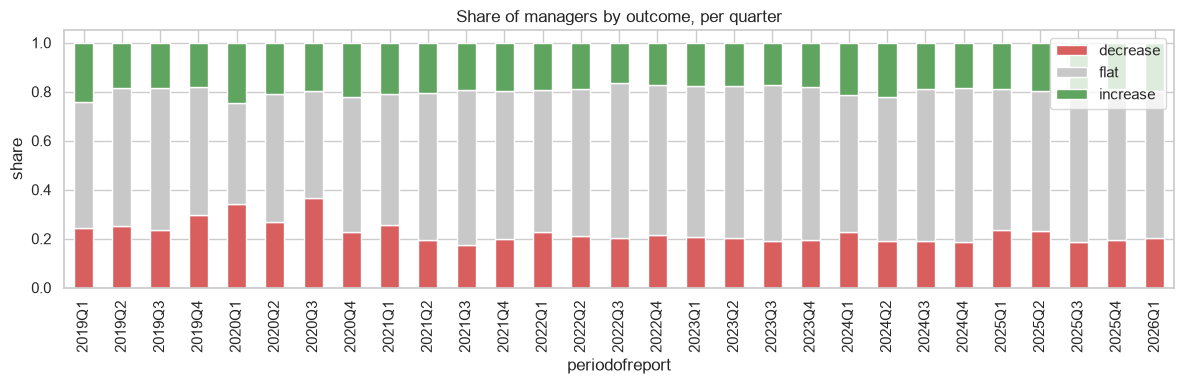

In [44]:
#Chart 1 Managers General Activity 

mix = pd.crosstab(clean_df["periodofreport"], clean_df["outcome"], normalize="index")[["decrease", "flat", "increase"]]
mix.index = mix.index.to_period("Q").astype(str)
mix.plot(kind="bar", stacked=True, figsize=(12, 4), color=["#d95f5f", "#c8c8c8", "#5fa55f"])
plt.title("Share of managers by outcome, per quarter"); plt.ylabel("share"); plt.legend(loc="upper right")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

The flat rates seem to be constant from 2022 forward, with some swelling during the 2020 periods. The fraction of managers who hold a stable amount of apple stock is quite stable. 

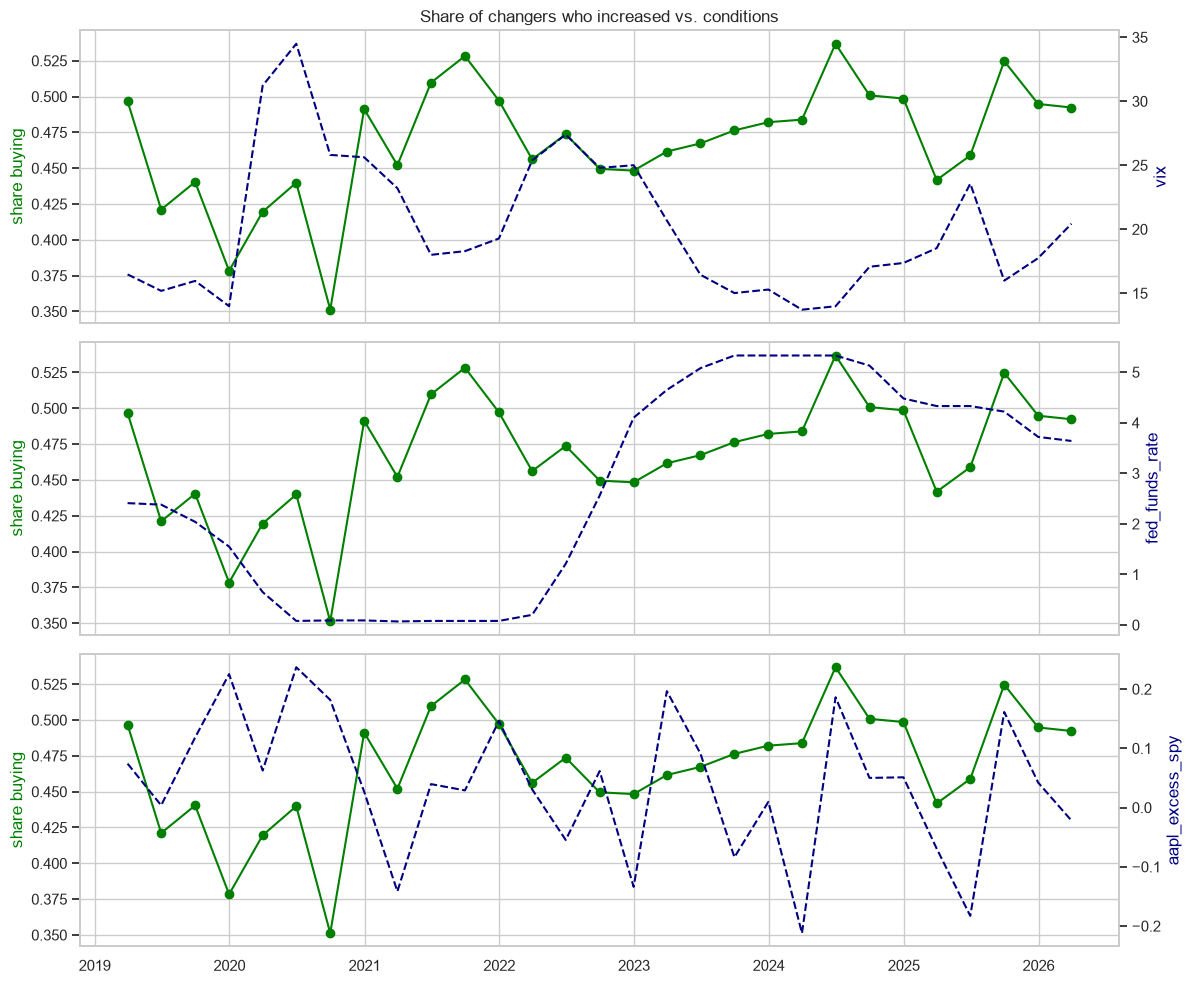

In [ ]:
#Chart 2  Visualization of managers activity with macro variables

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, var in zip(axes, ["vix", "fed_funds_rate", "aapl_excess_spy"]):
    ax.plot(q.index, q["share_increase"], color="green", marker="o", label="share buying")
    ax.set_ylabel("share buying", color="green")
    ax2 = ax.twinx()
    ax2.plot(q.index, q[var], color="navy", linestyle="--", label=var)
    ax2.set_ylabel(var, color="navy"); ax2.grid(False)
axes[0].set_title("Share of changers who increased vs. conditions")
plt.tight_layout(); plt.show()

vix (Fear Index) 
- high indication of correlation between vix and share buying. 
- when vix is high, shares bought are generally low. 

fed_funds_rate (Federal Interest Rate)
- even in 2021-22 with the rates near 0, apple share buying still had high variation
- weak correlation

aapl_excess_spy (Apple stock vs S&P500)
- there is no consistent pattern. Although apple may mirror S&P in some quarters, there doesn't seem to be an established pattern. 

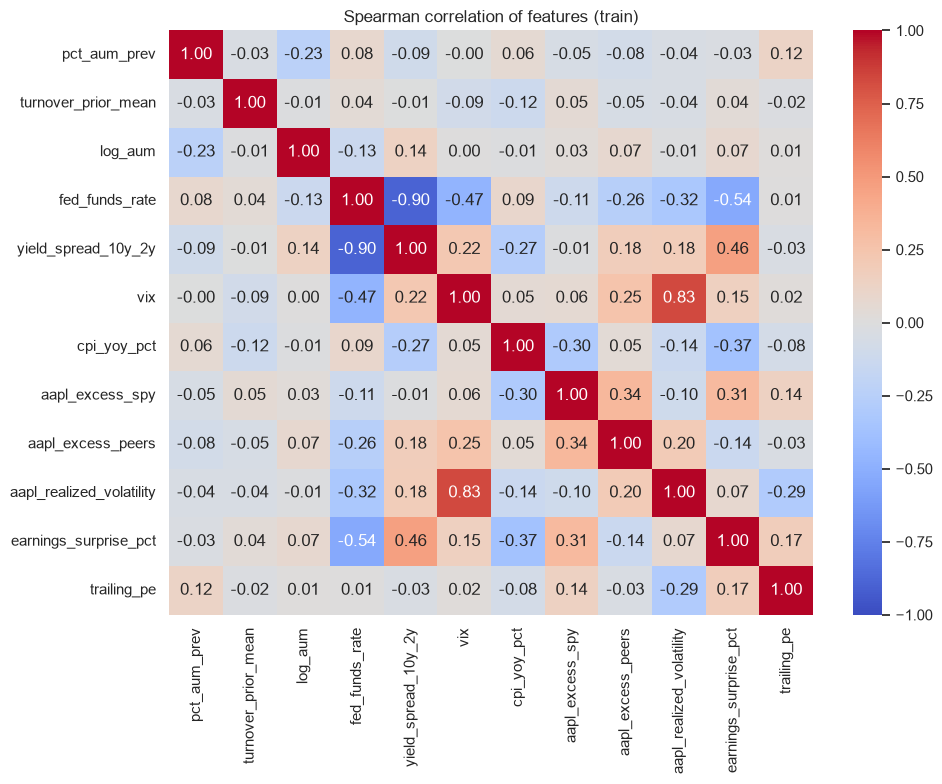

In [ ]:
#Chart 3 Which Features Overlap? 

corr = train[all_feats].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation of features (train)"); plt.tight_layout(); plt.show()

fed_funds_rate and yield_spread_10y_2y: -0.90 
- these two are essentially the same variable

vix and appl_realized_volatility: 0.83 
- the market's fear gauge and Apple's own volatility are nearly the same

fed_funds_rate and earnings_surprise_pct: -0.54
- large apple earnings happened when federal funds were low. this most likely funding changes. 

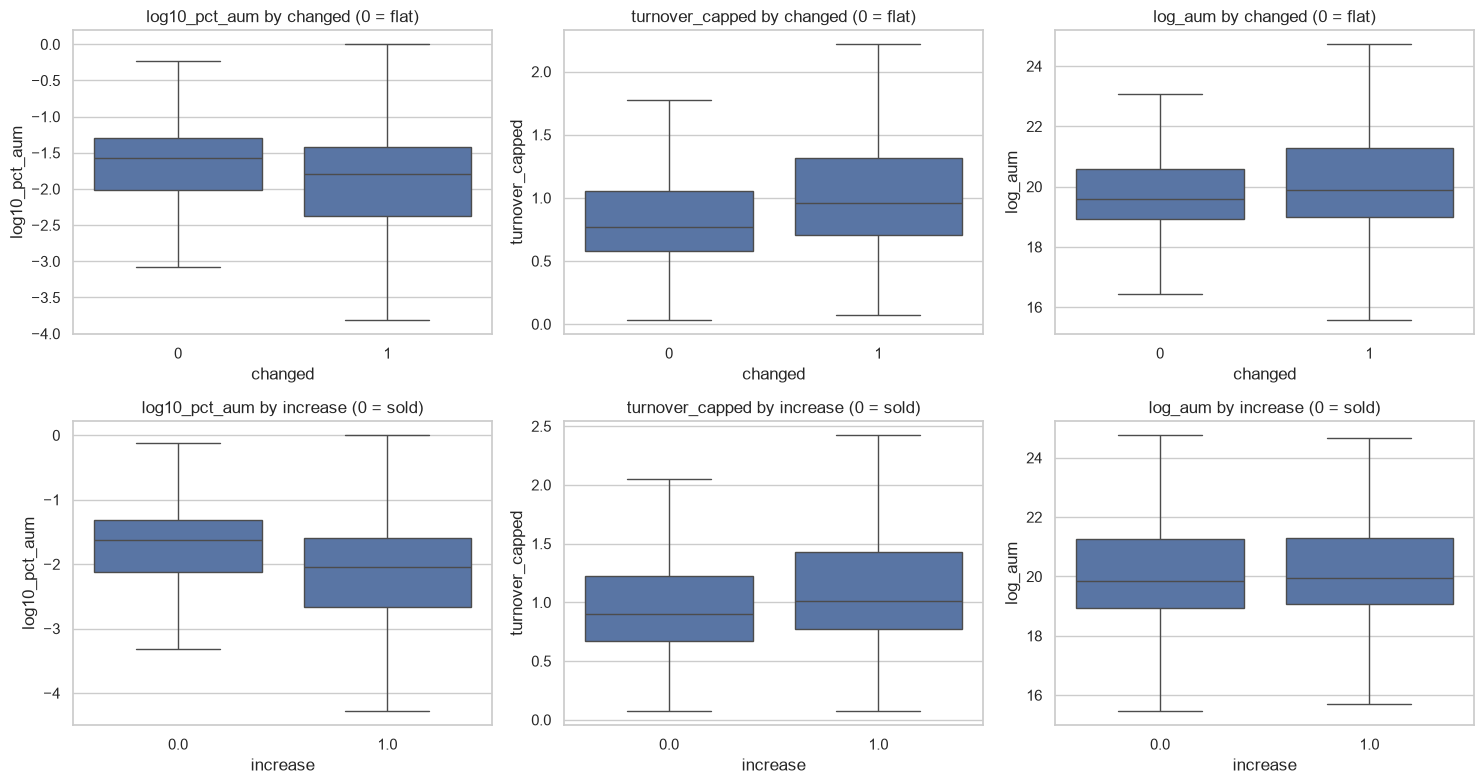

In [ ]:
#Chart 4 Do the features separate the groups?

plot_df = train.copy()
plot_df["log10_pct_aum"] = np.log10(plot_df["pct_aum_prev"].clip(lower=1e-8))
plot_df["turnover_capped"] = plot_df["turnover_prior_mean"].clip(upper=plot_df["turnover_prior_mean"].quantile(0.99))
cols = ["log10_pct_aum", "turnover_capped", "log_aum"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, c in enumerate(cols):
    sns.boxplot(data=plot_df, x="changed", y=c, ax=axes[0, i], showfliers=False)
    axes[0, i].set_title(f"{c} by changed (0 = flat)")
    sns.boxplot(data=plot_df[plot_df["changed"] == 1], x="increase", y=c, ax=axes[1, i], showfliers=False)
    axes[1, i].set_title(f"{c} by increase (0 = sold)")
plt.tight_layout(); plt.show()

Managers who had smaller holdings of Apple stock compared to their entire stock seemed to be more likely to change their holdings. 

Managers who have higher turnover (or trade more often) also seem to trade their apple stock. 

Managers with different total assets does not seem to influence whether they buy or sell. 

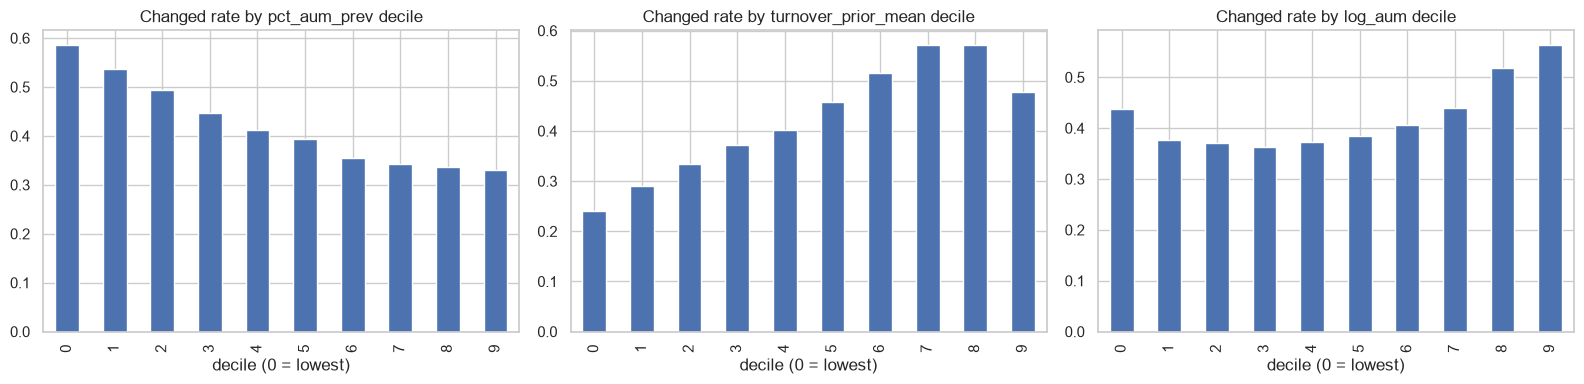

In [ ]:
#Chart 5 Rates by Bucket

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["pct_aum_prev", "turnover_prior_mean", "log_aum"]):
    bucket = pd.qcut(train[c], 10, labels=False, duplicates="drop")
    train.groupby(bucket)["changed"].mean().plot(kind="bar", ax=ax)
    ax.set_title(f"Changed rate by {c} decile"); ax.set_xlabel("decile (0 = lowest)")
plt.tight_layout(); plt.show()

First bar graph shows us that managers with small apple stake change more often 

Second bar graph shows that higher trading managers will trade apple stock more often 

Third graph shows that managers with different size assets doesn't contribute much to changing their hold in apple. 

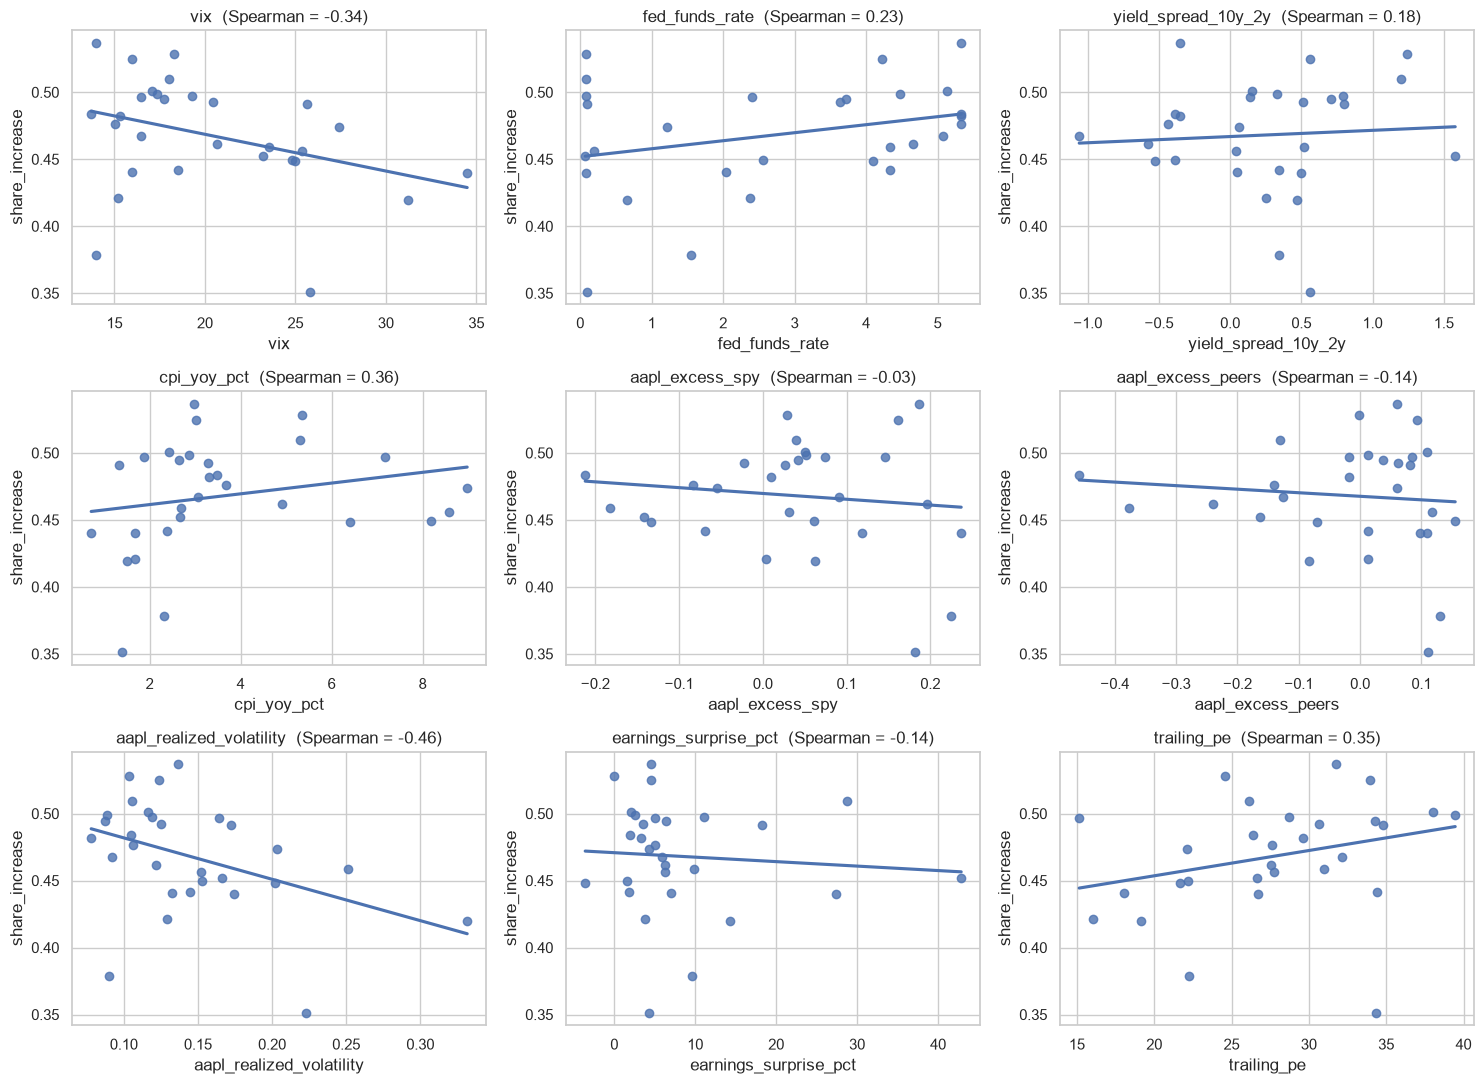

aapl_realized_volatility   -0.46
vix                        -0.34
aapl_excess_peers          -0.14
earnings_surprise_pct      -0.14
aapl_excess_spy            -0.03
yield_spread_10y_2y         0.18
fed_funds_rate              0.23
trailing_pe                 0.35
cpi_yoy_pct                 0.36
Name: share_increase, dtype: float64


In [ ]:
#Chart 6 quarter-level check 

vars_q = ["vix", "fed_funds_rate", "yield_spread_10y_2y", "cpi_yoy_pct",
          "aapl_excess_spy", "aapl_excess_peers", "aapl_realized_volatility",
          "earnings_surprise_pct", "trailing_pe"]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, v in zip(axes.ravel(), vars_q):
    sns.regplot(data=q, x=v, y="share_increase", ax=ax, ci=None)
    rho = q[[v, "share_increase"]].corr(method="spearman").iloc[0, 1]
    ax.set_title(f"{v}  (Spearman = {rho:.2f})")
plt.tight_layout(); plt.show()
print(q[vars_q + ["share_increase"]].corr(method="spearman")["share_increase"].drop("share_increase").round(2).sort_values())

It seems that no macro or apple variable clearly explains the buying vs selling. 

In [ ]:
#Data seems to have some extreme values in AUM and turnover, let's check how many rows are affected by this

aum = np.exp(clean_df["log_aum"])
print("rows with AUM > $5 trillion:", (aum > 5e12).sum())
print("rows with turnover > 3:", (clean_df["turnover_prior_mean"] > 3).sum())
print("total rows:", len(clean_df))

rows with AUM > $5 trillion: 89
rows with turnover > 3: 12404
total rows: 116305


In [ ]:
#Clean data before we move into regression analysis 

#Drop the 89 impossible-AUM rows

clean_df = clean_df[np.exp(clean_df["log_aum"]) <= 5e12].copy()

#Cap the turnover values

clean_df["turnover_extreme"] = (clean_df["turnover_prior_mean"] > 3).astype(int)
clean_df["turnover_prior_mean"] = clean_df["turnover_prior_mean"].clip(upper=3)

#Rebuild the train/test sets based off of the cleaned data

train = clean_df[clean_df["periodofreport"] < CUTOFF].copy()
test  = clean_df[clean_df["periodofreport"] >= CUTOFF].copy()
train_changed = train[train["changed"] == 1].copy()
test_changed  = test[test["changed"] == 1].copy()
train_changed["increase"] = train_changed["increase"].astype(int)
test_changed["increase"]  = test_changed["increase"].astype(int)


###Step 3

In [ ]:
#Prepare the data 

#clip outliers and center the pct_aum feature for modeling

clean_df["log10_pct_aum"] = np.log10(clean_df["pct_aum_prev"].clip(lower=1e-8))
aum_mean = clean_df.loc[clean_df["periodofreport"] < CUTOFF, "log_aum"].mean()
clean_df["log_aum_sq"] = (clean_df["log_aum"] - aum_mean) ** 2

#choose the features for modeling (slightly changed after visualization)

manager_feats = ["log10_pct_aum", "turnover_prior_mean", "log_aum", "log_aum_sq"]
macro_feats   = ["fed_funds_rate", "vix", "cpi_yoy_pct"]
apple_feats   = ["aapl_excess_spy", "aapl_excess_peers", "earnings_surprise_pct", "trailing_pe"]
raw_feats = manager_feats + macro_feats + apple_feats

#resplit the train/test sets for modeling

train = clean_df[clean_df["periodofreport"] < CUTOFF].copy()
test  = clean_df[clean_df["periodofreport"] >= CUTOFF].copy()

#scale features with sklearn StandardScaler and using z-scores to standardize the features for modeling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(train[raw_feats])
z_feats = [f + "_z" for f in raw_feats]
train[z_feats] = scaler.transform(train[raw_feats])
test[z_feats]  = scaler.transform(test[raw_feats])

#stage the datasets 

train_changed = train[train["changed"] == 1].copy()
test_changed  = test[test["changed"] == 1].copy()
train_changed["increase"] = train_changed["increase"].astype(int)
test_changed["increase"]  = test_changed["increase"].astype(int)

#3 different blocks of features for modeling (manager, macro, apple)

block1 = [f + "_z" for f in manager_feats]
block2 = block1 + [f + "_z" for f in macro_feats]
block3 = block2 + [f + "_z" for f in apple_feats]

In [65]:
#Stage 1 Manager Only Features 

# Defining Function: fit a logistic regression with standard errors clustered by quarter

def fit_logit(data, target, features):
    X = sm.add_constant(data[features])
    y = data[target]
    groups = pd.factorize(data["periodofreport"])[0]
    return sm.Logit(y, X).fit(disp=0, cov_type="cluster", cov_kwds={"groups": groups})

# Helper: turn coefficients into odds ratios with confidence ranges

def odds_table(model):
    ci = np.exp(model.conf_int())
    return pd.DataFrame({
        "odds_ratio": np.exp(model.params),
        "ci_low": ci[0],
        "ci_high": ci[1],
        "p_value": model.pvalues,
    }).round(3)

# Stage 1a: changed vs. flat (all train rows), manager features only

m1_s1 = fit_logit(train, "changed", block1)
print("STAGE 1a: changed vs. flat")
print(odds_table(m1_s1))
print("pseudo R-squared:", round(m1_s1.prsquared, 4))

# Stage 1b: bought vs. sold (changers only), manager features only

m1_s2 = fit_logit(train_changed, "increase", block1)
print("\nSTAGE 2a: bought vs. sold")
print(odds_table(m1_s2))
print("pseudo R-squared:", round(m1_s2.prsquared, 4))

STAGE 1a: changed vs. flat
                       odds_ratio  ci_low  ci_high  p_value
const                       0.728   0.657    0.806     0.00
log10_pct_aum_z             0.734   0.702    0.766     0.00
turnover_prior_mean_z       1.359   1.289    1.432     0.00
log_aum_z                   1.125   1.093    1.158     0.00
log_aum_sq_z                0.932   0.874    0.993     0.03
pseudo R-squared: 0.0325

STAGE 2a: bought vs. sold
                       odds_ratio  ci_low  ci_high  p_value
const                       0.735   0.668    0.810      0.0
log10_pct_aum_z             0.533   0.501    0.567      0.0
turnover_prior_mean_z       1.348   1.285    1.414      0.0
log_aum_z                   0.903   0.862    0.947      0.0
log_aum_sq_z                0.822   0.787    0.858      0.0
pseudo R-squared: 0.0652


Odd_ratio shows us how much the variable affects if they will change or remain flat / increased stock or decreased 

Stage 1a analysis
- the turnover is the highest factor on whether or not the manager will turn over 
- the % makeup of the stock being apple seems to sway managers to not change 
- the bigger managers with larger assets tend to change more often

Stage 1b analysis
- the percentage of apple in their stock profile seems to be a heavy influencer, the bigger the stock of apple the manager holds relative to the entire asset, the more likely they will not buy. 
- managers with higher past turnovers tend to buy more than sell 
- managers with larger assets lean toward selling rather than buying 

Both Pseudo R-squared are low, showing that the data is not able to be that well explained by the variables we have tested so far.  

In [ ]:
#Stage 2 Manager + Macro Features

def fit_logit(data, target, features):
    X = sm.add_constant(data[features])
    y = data[target]
    groups = pd.factorize(data["periodofreport"])[0]
    return sm.Logit(y, X).fit(disp=0, cov_type="cluster", cov_kwds={"groups": groups}, use_t=True)

m1_s1 = fit_logit(train, "changed", block1)
m2_s1 = fit_logit(train, "changed", block2)
m1_s2 = fit_logit(train_changed, "increase", block1)
m2_s2 = fit_logit(train_changed, "increase", block2)

print("STAGE 2a: changed vs. flat (manager + macro)")
print(odds_table(m2_s1))
print("\nSTAGE 2b: bought vs. sold (manager + macro)")
print(odds_table(m2_s2))

compare = pd.DataFrame({
    "pseudo_R2": [m1_s1.prsquared, m2_s1.prsquared, m1_s2.prsquared, m2_s2.prsquared],
    "AIC":       [m1_s1.aic,       m2_s1.aic,       m1_s2.aic,       m2_s2.aic],
}, index=["Stage 1a: manager only", "Stage 2a: + macro", "Stage 1b: manager only", "Stage 2b: + macro"]).round(4)
print("\n", compare)

STAGE 2a: changed vs. flat (manager + macro)
                       odds_ratio  ci_low  ci_high  p_value
const                       0.726   0.683    0.771    0.000
log10_pct_aum_z             0.741   0.711    0.773    0.000
turnover_prior_mean_z       1.370   1.304    1.440    0.000
log_aum_z                   1.114   1.080    1.149    0.000
log_aum_sq_z                0.941   0.879    1.007    0.077
fed_funds_rate_z            0.944   0.897    0.993    0.027
vix_z                       1.134   1.021    1.259    0.021
cpi_yoy_pct_z               0.888   0.823    0.958    0.004

STAGE 2b: bought vs. sold (manager + macro)
                       odds_ratio  ci_low  ci_high  p_value
const                       0.742   0.685    0.804    0.000
log10_pct_aum_z             0.530   0.495    0.568    0.000
turnover_prior_mean_z       1.357   1.283    1.435    0.000
log_aum_z                   0.908   0.866    0.953    0.000
log_aum_sq_z                0.815   0.780    0.851    0.000
fed_funds_

Stage 2a analysis
- Confirms VIX (fear factor) influences Apple Holding more often 
- FED Interest Rate and CPI show that higher inflation rates slightly influence whether managers change, but not too much 
- macro data shows very weak correlation on whether or not managers changed stock holding 

Stage 2b analysis 
- Vix shows that if fear is rising, managers tend to sell more (very slightly)
- Fed Interest Rate and CPI show that higher of either correlates to more likely to buy. 

Pseudo_R^2 still remains low, meaning that these variables still don't tell the full situation. 

In [61]:
#Step 3 Manager + Macro + Apple Features

#Fit Stage 3a (changed vs. flat) and 3b (bought vs. sold): manager + macro + Apple

m3_s1 = fit_logit(train, "changed", block3)
m3_s2 = fit_logit(train_changed, "increase", block3)

print("STAGE 3a: changed vs. flat (manager + macro + Apple)")
print(odds_table(m3_s1))
print("\nSTAGE 3b: bought vs. sold (manager + macro + Apple)")
print(odds_table(m3_s2))

#Do the 4 Apple variables add anything as a group? 

apple_z = [f + "_z" for f in apple_feats]
def joint_p(model, names):
    R = np.zeros((len(names), len(model.params)))
    for i, n in enumerate(names):
        R[i, list(model.params.index).index(n)] = 1
    return float(model.wald_test(R, scalar=True).pvalue)

print("\nJoint test, Apple variables as a group (p-value):")
print("  3a:", round(joint_p(m3_s1, apple_z), 3), "| 3b:", round(joint_p(m3_s2, apple_z), 3))

#Side-by-side comparison of all six models

compare = pd.DataFrame({
    "pseudo_R2": [m1_s1.prsquared, m2_s1.prsquared, m3_s1.prsquared,
                  m1_s2.prsquared, m2_s2.prsquared, m3_s2.prsquared],
    "AIC":       [m1_s1.aic, m2_s1.aic, m3_s1.aic,
                  m1_s2.aic, m2_s2.aic, m3_s2.aic],
}, index=["1a: manager", "2a: + macro", "3a: + Apple",
          "1b: manager", "2b: + macro", "3b: + Apple"]).round(4)
print("\n", compare)

STAGE 3a: changed vs. flat (manager + macro + Apple)
                         odds_ratio  ci_low  ci_high  p_value
const                         0.726   0.685    0.769    0.000
log10_pct_aum_z               0.743   0.713    0.774    0.000
turnover_prior_mean_z         1.371   1.304    1.440    0.000
log_aum_z                     1.117   1.083    1.151    0.000
log_aum_sq_z                  0.940   0.878    1.006    0.072
fed_funds_rate_z              0.902   0.766    1.062    0.202
vix_z                         1.141   1.041    1.250    0.007
cpi_yoy_pct_z                 0.875   0.814    0.940    0.001
aapl_excess_spy_z             1.005   0.948    1.066    0.855
aapl_excess_peers_z           0.963   0.873    1.062    0.431
earnings_surprise_pct_z       0.941   0.809    1.094    0.405
trailing_pe_z                 0.994   0.925    1.068    0.868

STAGE 3b: bought vs. sold (manager + macro + Apple)
                         odds_ratio  ci_low  ci_high  p_value
const                     

analysis: 
- Apple's own news explains almost nothing about whether managers change their holdings. 
- both in stage 3a and 3b, all of the odd_s ratio had a negligible effect on both whether there was a change in assets held in apple, or whether or not the managers increased of decreased. 
- pseudo R2 also only increased by .0003 and .002 between the 2nd and 3rd stage, showing that it explained nearly none of the variance in stock holdings. 


             train_AUC  test_AUC     gap
model                                   
1a: manager     0.6328    0.6276  0.0051
2a: + macro     0.6400    0.6256  0.0144
3a: + Apple     0.6397    0.6264  0.0133
1b: manager     0.6759    0.6284  0.0475
2b: + macro     0.6795    0.6288  0.0507
3b: + Apple     0.6823    0.6223  0.0600

Stage a (changed vs. flat):
  + macro adds: -0.0021
  + Apple adds: 0.0008

Stage b (bought vs. sold):
  + macro adds: 0.0004
  + Apple adds: -0.0065

Test AUC by quarter (9 quarters):
               min  median    max
model                            
1a: manager  0.614   0.627  0.653
2a: + macro  0.615   0.628  0.654
3a: + Apple  0.614   0.628  0.654
1b: manager  0.609   0.626  0.650
2b: + macro  0.610   0.626  0.650
3b: + Apple  0.610   0.627  0.650


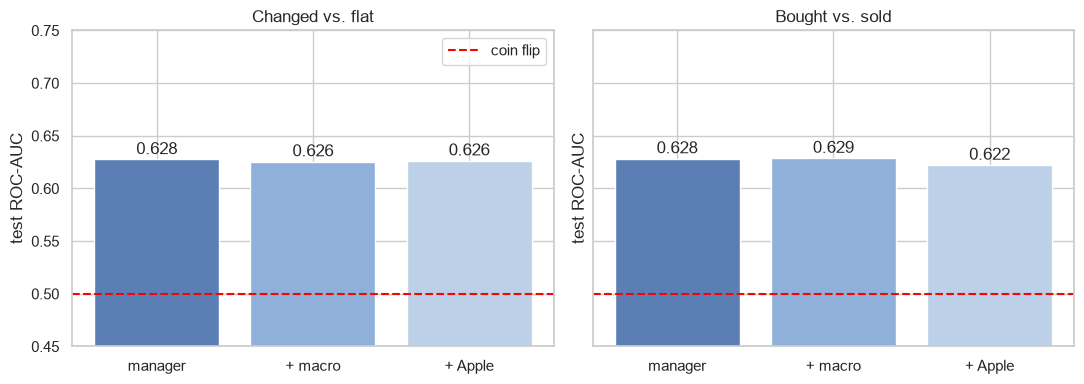

In [ ]:
from sklearn.metrics import roc_auc_score

#Setup: each model, the data it was fit on, the matching test data, and its features
models = {
    "1a: manager":  (m1_s1, block1, train,         test,         "changed"),
    "2a: + macro":  (m2_s1, block2, train,         test,         "changed"),
    "3a: + Apple":  (m3_s1, block3, train,         test,         "changed"),
    "1b: manager":  (m1_s2, block1, train_changed, test_changed, "increase"),
    "2b: + macro":  (m2_s2, block2, train_changed, test_changed, "increase"),
    "3b: + Apple":  (m3_s2, block3, train_changed, test_changed, "increase"),
}

def score(model, feats, data, target):
    X = sm.add_constant(data[feats], has_constant="add")
    return roc_auc_score(data[target], model.predict(X))

#Train vs. test AUC for every model
rows = []
for name, (mdl, feats, tr, te, target) in models.items():
    rows.append({"model": name,
                 "train_AUC": score(mdl, feats, tr, target),
                 "test_AUC":  score(mdl, feats, te, target)})
auc = pd.DataFrame(rows).set_index("model")
auc["gap"] = auc["train_AUC"] - auc["test_AUC"]
print(auc.round(4))

#print the influence of each block of features on the test AUC? 
for s, label in [("a", "changed vs. flat"), ("b", "bought vs. sold")]:
    base = auc.loc[f"1{s}: manager", "test_AUC"]
    print(f"\nStage {s} ({label}):")
    print("  + macro adds:", round(auc.loc[f"2{s}: + macro", "test_AUC"] - base, 4))
    print("  + Apple adds:", round(auc.loc[f"3{s}: + Apple", "test_AUC"] - auc.loc[f"2{s}: + macro", "test_AUC"], 4))

#Test the performance of each model by quarter
qrows = []
for name, (mdl, feats, tr, te, target) in models.items():
    per_q = [score(mdl, feats, g, target)
             for _, g in te.groupby("periodofreport") if g[target].nunique() == 2]
    qrows.append({"model": name, "min": min(per_q), "median": np.median(per_q), "max": max(per_q)})
print("\nTest AUC by quarter (9 quarters):")
print(pd.DataFrame(qrows).set_index("model").round(3))

#Chart: test AUC by model
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, s, title in [(axes[0], "a", "Changed vs. flat"), (axes[1], "b", "Bought vs. sold")]:
    names = [f"1{s}: manager", f"2{s}: + macro", f"3{s}: + Apple"]
    ax.bar([n.split(": ")[1] for n in names], auc.loc[names, "test_AUC"], color=["#5b7fb5", "#8fb0d8", "#bcd0e8"])
    ax.axhline(0.5, color="red", linestyle="--", label="coin flip")
    ax.set_ylim(0.45, 0.75); ax.set_title(title); ax.set_ylabel("test ROC-AUC")
    for i, n in enumerate(names):
        ax.text(i, auc.loc[n, "test_AUC"] + 0.005, f"{auc.loc[n, 'test_AUC']:.3f}", ha="center")
axes[0].legend(); plt.tight_layout(); plt.show()

Analysis: 

- Looking at that the changed vs flat and the bought vs sold for manager only both have a .628 AUC, which indicates that the model ranks a randomly chosen changer above a randomly chosen-non-changer 62.8% of the time. 
- Adding on Macro and Apple data has negligible effect on both. 
- According to the graph. adding Apple data made the predictions worse on whether or not managers bought vs sold 

####Conclusions drawn with regression analysis 

Manager Characteristics (like amount of Apple stock that makes up portfolio and past trading activity) correcly indicated whether or not they will change / sell vs buy 63% of the time.

Adding macro conditions and Apple-specific conditions did not improve the prediction. 

Recommendations: 
- changes in Apple holdings for managers look more like routine portfolio shifts than changes in the economy and specific apple related news. 

###Step 4

             cv_AUC  test_AUC  logit_test_AUC  xgb_minus_logit
model                                                         
1a: manager  0.6701    0.6661          0.6276           0.0385
2a: + macro  0.6730    0.6618          0.6256           0.0362
3a: + Apple  0.6710    0.6649          0.6264           0.0385
1b: manager  0.6875    0.6453          0.6284           0.0169
2b: + macro  0.6907    0.6423          0.6288           0.0135
3b: + Apple  0.6891    0.6435          0.6223           0.0212

Best settings:
model
1a: manager    {'max_depth': 4, 'min_child_weight': 20, 'n_es...
2a: + macro    {'max_depth': 4, 'min_child_weight': 20, 'n_es...
3a: + Apple    {'max_depth': 4, 'min_child_weight': 20, 'n_es...
1b: manager    {'max_depth': 4, 'min_child_weight': 20, 'n_es...
2b: + macro    {'max_depth': 4, 'min_child_weight': 20, 'n_es...
3b: + Apple    {'max_depth': 3, 'min_child_weight': 20, 'n_es...

Stage a (changed vs. flat):  + macro adds -0.0044 | + Apple adds +0.0032

Stage b (

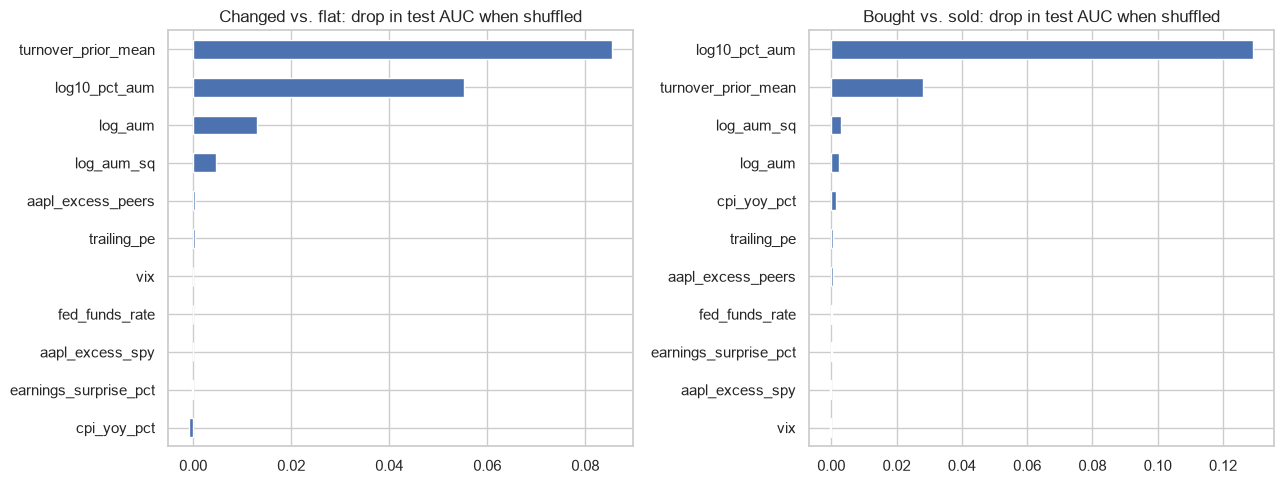

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.inspection import permutation_importance

#same six models as before: (features, train data, test data, target)
specs = {
    "1a: manager": (block1, train,         test,         "changed"),
    "2a: + macro": (block2, train,         test,         "changed"),
    "3a: + Apple": (block3, train,         test,         "changed"),
    "1b: manager": (block1, train_changed, test_changed, "increase"),
    "2b: + macro": (block2, train_changed, test_changed, "increase"),
    "3b: + Apple": (block3, train_changed, test_changed, "increase"),
}

#set the parameters
cv_params = {"max_depth": [2, 3, 4],
        "n_estimators": [100, 300],
        "min_child_weight": [20, 100]}

#run the machine learning!
xgb_models, rows = {}, []
for name, (feats, tr, te, target) in specs.items():
    base = XGBClassifier(learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                         tree_method="hist", eval_metric="auc", random_state=42, n_jobs=-1)
    groups = pd.factorize(tr["periodofreport"])[0]
    gs = GridSearchCV(base, cv_params, scoring="roc_auc", cv=GroupKFold(n_splits=5), n_jobs=1)
    gs.fit(tr[feats], tr[target], groups=groups)
    best = gs.best_estimator_
    xgb_models[name] = best
    rows.append({"model": name,
                 "cv_AUC":   gs.best_score_,
                 "test_AUC": roc_auc_score(te[target], best.predict_proba(te[feats])[:, 1]),
                 "best_params": gs.best_params_})

xgb_res = pd.DataFrame(rows).set_index("model")
xgb_res["logit_test_AUC"] = auc["test_AUC"]           
xgb_res["xgb_minus_logit"] = xgb_res["test_AUC"] - xgb_res["logit_test_AUC"]
print(xgb_res[["cv_AUC", "test_AUC", "logit_test_AUC", "xgb_minus_logit"]].round(4))
print("\nBest settings:")
print(xgb_res["best_params"].to_string())

#influence of each block of features on the test AUC for the XGBoost models
for s, label in [("a", "changed vs. flat"), ("b", "bought vs. sold")]:
    t = xgb_res["test_AUC"]
    print(f"\nStage {s} ({label}):  + macro adds {t[f'2{s}: + macro'] - t[f'1{s}: manager']:+.4f}"
          f" | + Apple adds {t[f'3{s}: + Apple'] - t[f'2{s}: + macro']:+.4f}")

#permutation importance on the TEST set for the full models (3a, 3b)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name, title in [(axes[0], "3a: + Apple", "Changed vs. flat"),
                        (axes[1], "3b: + Apple", "Bought vs. sold")]:
    feats, tr, te, target = specs[name]
    pi = permutation_importance(xgb_models[name], te[feats], te[target],
                                scoring="roc_auc", n_repeats=5, random_state=0)
    imp = pd.Series(pi.importances_mean, index=[f.replace("_z", "") for f in feats]).sort_values()
    imp.plot(kind="barh", ax=ax); ax.set_title(f"{title}: drop in test AUC when shuffled")
    print(f"\n{name} importance:\n", imp.sort_values(ascending=False).round(4).to_string())
plt.tight_layout(); plt.show()

Analysis: 

XGBoost's test AUC was slightly higher than the logtistic regression's AUC, by up to 3 percent across the board. 

IF we look at the graph, we see that the most important predictors of the XGB models were the turover_prior_mean and the log10_pct_aum, which are both manager features. 
- macro and apple contribution to the prediction were negligible.

##Conclusions, Findings and Recommendations

The change in larger managers holdings of apple stock can be most closely explained by the manager's's own characteritcs, not macroeconomic conditions or Apple-specific news, but there is still other unknown factors that are largely influencing manager decisions to hold, sell, or buy. 

Looking at all of the managers and their apple stock, I modeled 2 questions: whether a mangaer changed its position (defined by a 5% change in shares held), and if they did, whether they bought or sold. 

Most notable findings of the logistic regression models that were clustered by quarter showed that managers with larger Apple positions were less likely to change them and more likely to sell when they did decide to shift their portfolios (odds ratio of 0.53 per increase in standard deviation of apple stock's held), while managers who trade heavily in general were more likly to change their apple holdings (odds ratio of 1.37). Macro variables had some influence, such as VIX (fear factor) influencing changes in portfolio holdings (odds ratio of 1.14), and higher inflation with fewer changes (odds ratio of 0.88). Apple specific influences were negligible (odds ratios of +=.1)

Both logistic models and XGBoost models trained on the data performed relatively poorly when run on 2024-26 test data, resulting in 0.63 and 0.67 AUC respectively. Adding macro or apple factors changed test AUC by less than 0.01 for both models. 

A 0.67 AUC indicates a weak prediction, even if they do slightly better than random guessing. These tests show that managers are most likely acting on factors that go beyond typical manager behavior, macro economic conditions, and apple specific performance compared to the general stock market and peer competitors. 

Recommendations:
- For smaller individual investors, manager specific variables can most strongly explain their holdings of apple stock, but much of their behavior remains unexplained by both macro-economic factors and apple-specific performance. 
- In making decisions on whether to follow larger manager portfolios should look at factors beyond the variables focused on in this study. 